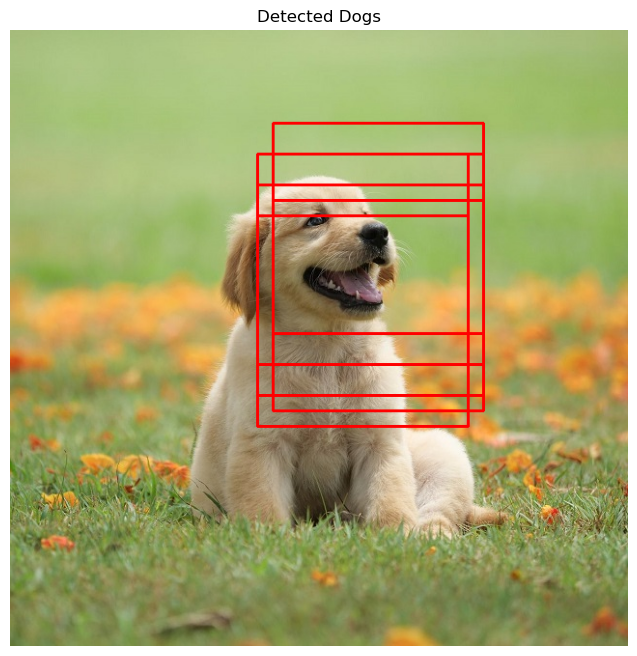

In [5]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the pre-trained MobileNetV2 model with ImageNet weights
model = MobileNetV2(weights='imagenet')

# Load the input image
image = cv2.imread('images/dog01.jpg')
orig = image.copy()
(H, W) = image.shape[:2]

# Sliding window parameters
window_size = (218, 218)  # size of the sliding window
step_size = 16            # stride of the sliding window

boxes = []

# Sliding window generator
def sliding_window(image, step, window_size):
    for y in range(0, image.shape[0] - window_size[1], step):
        for x in range(0, image.shape[1] - window_size[0], step):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

# Scan the image using sliding window
for (x, y, window) in sliding_window(image, step_size, window_size):
    # Skip windows that do not match the expected size
    if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
        continue

    # Preprocess the region of interest (ROI) and classify it
    roi = cv2.resize(window, (224, 224))
    roi = roi.astype("float32")
    roi = preprocess_input(np.expand_dims(roi, axis=0))

    preds = model.predict(roi, verbose=0)
    label = decode_predictions(preds, top=1)[0][0]

    # If the top prediction is a dog with confidence > 0.3, save the bounding box
    if 'dog' in label[1].lower() and preds[0][np.argmax(preds)] > 0.3:
        boxes.append((x, y, x + window_size[0], y + window_size[1]))

# Draw red bounding boxes on the original image
for (startX, startY, endX, endY) in boxes:
    cv2.rectangle(orig, (startX, startY), (endX, endY), (0, 0, 255), 2)

# Display the result image
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Dogs")
plt.show()


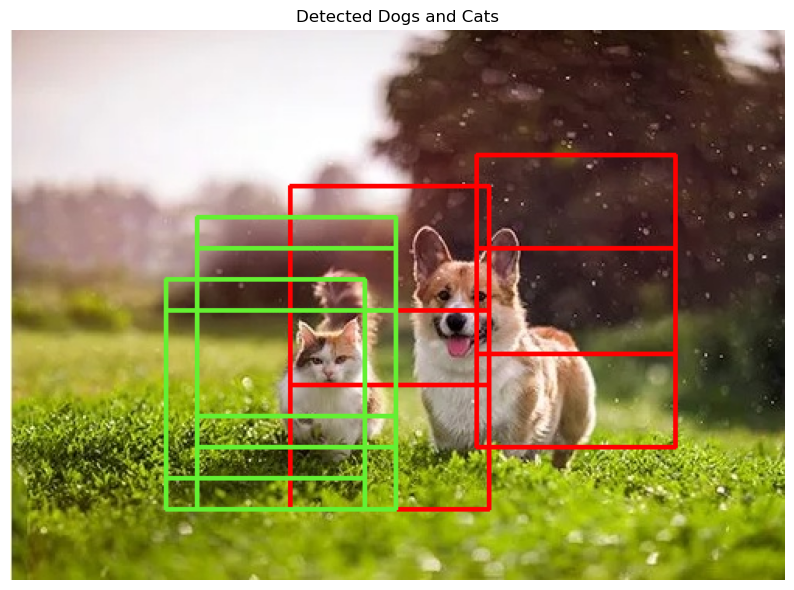

In [6]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the pre-trained MobileNetV2 model with ImageNet weights
model = MobileNetV2(weights='imagenet')

# Load the input image
image = cv2.imread('images/dogcat.jpg')
orig = image.copy()
(H, W) = image.shape[:2]

# Sliding window parameters
window_size = (128, 128)  # size of the sliding window
step_size = 20            # stride of the sliding window

box_dogs = []
box_cats = []

# Sliding window generator function
def sliding_window(image, step, window_size):
    for y in range(0, image.shape[0] - window_size[1], step):
        for x in range(0, image.shape[1] - window_size[0], step):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

# Scan the image using the sliding window
for (x, y, window) in sliding_window(image, step_size, window_size):
    # Skip windows that do not match the expected size
    if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
        continue

    # Preprocess the region of interest (ROI) and classify it
    roi = cv2.resize(window, (224, 224))
    roi = roi.astype("float32")
    roi = preprocess_input(np.expand_dims(roi, axis=0))

    preds = model.predict(roi, verbose=0)
    label = decode_predictions(preds, top=1)[0][0]

    # Check if the prediction is a dog or cat with confidence > 0.1
    if 'dog' in label[1].lower() and preds[0][np.argmax(preds)] > 0.1:
        box_dogs.append((x, y, x + window_size[0], y + window_size[1]))
    elif 'cat' in label[1].lower() and preds[0][np.argmax(preds)] > 0.1:
        box_cats.append((x, y, x + window_size[0], y + window_size[1]))

# Draw red bounding boxes for detected dogs
for (startX, startY, endX, endY) in box_dogs:
    cv2.rectangle(orig, (startX, startY), (endX, endY), (0, 0, 255), 2)

# Draw green bounding boxes for detected cats
for (startX, startY, endX, endY) in box_cats:
    cv2.rectangle(orig, (startX, startY), (endX, endY), (50, 240, 100), 2)

# Display the result image
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Dogs and Cats")
plt.show()
